In [57]:
import sys, os, os.path as op
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import arviz as az

bids_folder      = '/Users/mrenke/data/ds-dnumrisk'
phenotype_folder = op.join(bids_folder, 'derivatives', 'phenotype')
out_folder       = op.join(bids_folder, 'plots_and_ims', 'paper_riskDD')
figures_folder   = op.join(out_folder, 'figures')
results_folder   = op.join(out_folder, 'results')


In [58]:
risk_ns = pd.read_csv(op.join(results_folder,"probit_nonsym_subwise_summary.csv")).set_index(['subject','group_label'])
risk_s = pd.read_csv(op.join(results_folder,"probit_sym_subwise_summary.csv")).set_index(['subject','group_label'])

risk_ns.rename(columns={col:f'risk_ns_{col}' for col in risk_ns.columns}, inplace=True)
risk_s.rename(columns={col:f'risk_s_{col}' for col in risk_s.columns}, inplace=True)

df_comb = risk_ns.join(risk_s)

In [ ]:
# eyetracking (only smybolic format)
format = 'non-symbolic'  # 'symbolic' or 'non-symbolic'
eyetrack_dur_diff = pd.read_csv(op.join(phenotype_folder, f'subwise_duration_option_difference_abs_{format}.tsv')).set_index('subject')
df_comb = risk_ns.join(risk_s).join(eyetrack_dur_diff, on='subject')
df_comb.head()

In [30]:
var_comb_of_interest = [['risk_s_ind_point_ss_slope', 'risk_ns_ind_point_ss_slope'], 
                        ['risk_s_gamma_ss_slope', 'risk_ns_gamma_ss_slope'],
                        ['risk_ns_gamma_ss_slope', 'duration_option_difference_abs'],
                        ['risk_ns_ind_point_ss_slope', 'duration_option_difference_abs']]

In [ ]:
# correlate all variables in the dataframe
import itertools
import pingouin

vars = df_comb#.columns.drop(['group'])

tmp = df_comb.reset_index() # reset index to have 'group' as a column for hue in the plot
for x_var, y_var in var_comb_of_interest: # itertools.combinations(vars, 2):
    cor = pingouin.corr(tmp[y_var], tmp [x_var], method = 'spearman') #defautl: two -sided & pearson
    r_ = np.round(cor['r'][0], 2)
    p = np.round(cor['p-val'][0], 3)
    #print(f'{x_var} vs {y_var}: r={r_}, p= {p}')
    fig = sns.lmplot(x=x_var, y=y_var, data=tmp, hue='group_label',height=4) #, hue='group' hue='group',
    fig.set(title=f' r={r_}, p= {p}') 
    #plt.savefig(op.join(plot_folder, f'corr_groups-both_{x_var}_vs_{y_var}.png'), dpi=300, bbox_inches='tight')

In [32]:
df_comb

,,risk_ns_ind_point_map,risk_ns_ind_point_ss_slope,risk_ns_gamma_map,risk_ns_gamma_ss_slope,risk_s_ind_point_map,risk_s_ind_point_ss_slope,risk_s_gamma_map,risk_s_gamma_ss_slope,duration_option_difference_abs
subject,group_label,,,,,,,,,
1,Control,1.299868,-0.017499,2.727395,0.033422,0.980567,-0.012812,4.541565,0.033833,67.365079
2,Dyscalculic,1.355265,-0.048756,2.458620,0.069909,1.436467,-0.064109,2.362721,0.079218,103.021277
3,Control,1.549503,-0.061455,1.896559,0.055804,2.034652,-0.097699,2.110666,0.079296,18.931937
4,Dyscalculic,1.025408,-0.004299,2.911194,0.032755,1.264522,-0.040138,3.583629,0.086477,49.593750
5,Control,0.987040,-0.019138,2.199800,0.026687,0.926337,-0.026881,3.403458,0.069389,2.780749
...,...,...,...,...,...,...,...,...,...,...
62,Control,0.811828,0.017996,2.422240,-0.042566,0.755714,-0.008099,4.513681,0.011744,14.395833
63,Control,1.322033,-0.026522,2.699886,0.049028,1.377382,-0.040596,3.340885,0.081785,68.638743
64,Control,0.264733,-0.009528,4.006091,0.057333,0.431879,-0.014982,4.706840,0.090888,80.322917


/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_67123/630917083.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_ = np.round(cor['r'][0], 2)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_67123/630917083.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p = np.round(cor['p-val'][0], 3)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_67123/630917083.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.il

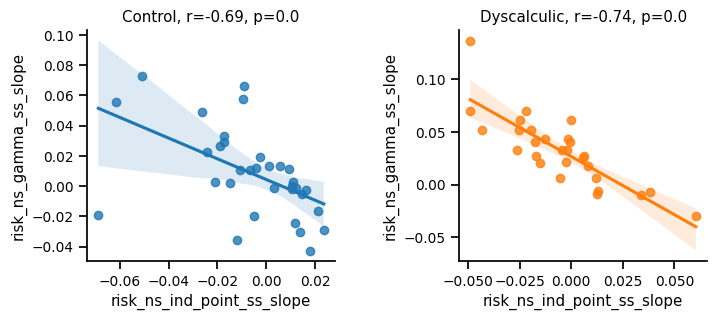

In [19]:
sns.set_context('notebook', font_scale=0.9)
fig,ax = plt.subplots(1,2, figsize=(8,3))
colors = [sns.color_palette()[0], sns.color_palette()[1]]

x_var =  'risk_ns_ind_point_ss_slope'
y_var = 'risk_ns_gamma_ss_slope'

for i,group in enumerate(['Control', 'Dyscalculic']):
    tmp = df_comb.xs(group, level='group_label')
    cor = pingouin.corr(tmp[y_var], tmp[x_var], method = 'shepherd')
    r_ = np.round(cor['r'][0], 2)
    p = np.round(cor['p-val'][0], 3)

    sns.regplot(x=x_var, y=y_var, data=tmp, ax=ax[i], color=colors[i])
    ax[i].set(title=f'{group}, r={r_}, p={p}', ylabel=y_var, xlabel=x_var)
    sns.despine()

plt.subplots_adjust(wspace=0.5)

# PCA on risk-task measures + correlation with questionnaires

**Step 1** — PCA on the 8 subwise probit estimates (ind_point & γ, MAP & SS-slope, × 2 formats).
Biplot coloured by group reveals strategy dimensions and whether dyscalculics cluster separately.

**Step 2** — Correlate PC1/PC2 scores with questionnaire measures (IQ, WM, math skill, everyday-life score).

In [59]:
# load questionnaire measures
iq       = pd.read_csv(op.join(phenotype_folder, 'iq-scores_ids2.csv')).set_index('subject')[['mean_iq']]
wm       = pd.read_csv(op.join(phenotype_folder, 'visio-spatial-WM_CBTtask-params.csv')).set_index('subject')[['erfassungsspanne']]
math     = pd.read_csv(op.join(phenotype_folder, 'math_skill&confidence&anxiety-means.csv')).set_index('subject')[['skill_score', 'anx_mean', 'conf_mean']]
everyday = pd.read_csv(op.join(phenotype_folder, 'everyday_life_numSituations.csv')).set_index('subject')[['mean_score']].rename(columns={'mean_score': 'everyday_life'})

questionnaires = iq.join(wm).join(math).join(everyday)
questionnaires.head()

,mean_iq,erfassungsspanne,skill_score,anx_mean,conf_mean,everyday_life
subject,,,,,,
1,112.5,8,36.0,1.333333,2.666667,2.142857
2,97.5,6,6.0,2.666667,0.666667,4.428571
3,105.0,5,29.0,1.666667,3.333333,2.357143
4,107.5,6,34.0,4.000000,1.833333,3.214286
5,102.5,7,30.0,2.000000,2.333333,1.714286


Top loadings on PC1:
risk_ns_gamma_map             0.509
risk_s_gamma_map              0.461
risk_ns_ind_point_map        -0.459
risk_s_ind_point_map         -0.444
risk_s_gamma_ss_slope         0.253
risk_ns_gamma_ss_slope        0.219
risk_s_ind_point_ss_slope     0.089
risk_ns_ind_point_ss_slope    0.003
dtype: float64

Top loadings on PC2:
risk_ns_gamma_ss_slope        0.554
risk_ns_ind_point_ss_slope   -0.514
risk_s_ind_point_ss_slope    -0.414
risk_s_gamma_ss_slope         0.338
risk_s_ind_point_map          0.265
risk_ns_ind_point_map         0.220
risk_ns_gamma_map             0.146
risk_s_gamma_map             -0.052
dtype: float64


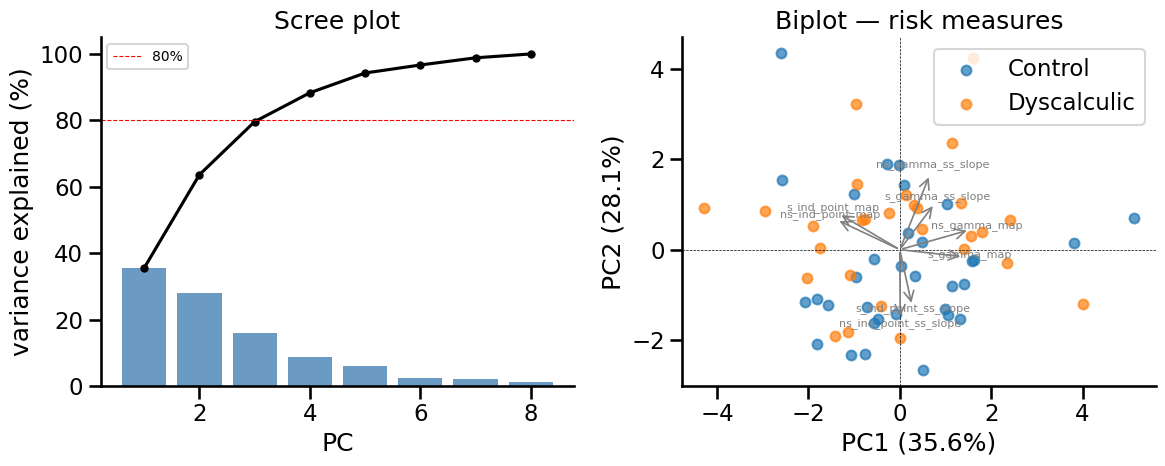

In [60]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

risk_cols = [c for c in df_comb.columns if c.startswith('risk_')]
X = df_comb[risk_cols].dropna()

# standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)
scores = pd.DataFrame(pca.transform(X_scaled), index=X.index, columns=[f'PC{i+1}' for i in range(len(risk_cols))])
scores['group_label'] = scores.index.get_level_values('group_label')

# --- figure: variance explained + biplot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.set_context('talk')

# left: scree plot
var_exp = pca.explained_variance_ratio_ * 100
axes[0].bar(range(1, len(var_exp)+1), var_exp, color='steelblue', alpha=0.8)
axes[0].plot(range(1, len(var_exp)+1), np.cumsum(var_exp), 'ko-', ms=5)
axes[0].axhline(80, color='r', ls='--', lw=0.8, label='80%')
axes[0].set(xlabel='PC', ylabel='variance explained (%)', title='Scree plot')
axes[0].legend(fontsize=10)

# right: biplot PC1 × PC2, coloured by group
pal = {'Control': sns.color_palette()[0], 'Dyscalculic': sns.color_palette()[1]}
scores = scores.drop(columns=['group_label'])  # drop cause info already in index
for grp, grp_df in scores.groupby('group_label'):
    axes[1].scatter(grp_df['PC1'], grp_df['PC2'], color=pal[grp], label=grp, alpha=0.7, s=50)

# loading arrows (scaled for visibility)
loadings = pca.components_.T  # shape (n_features, n_pcs)
scale = 3
short_names = {c: c.replace('risk_ns_','ns_').replace('risk_s_','s_') for c in risk_cols}
for i, feat in enumerate(risk_cols):
    axes[1].annotate('', xy=(loadings[i,0]*scale, loadings[i,1]*scale), xytext=(0,0),
                     arrowprops=dict(arrowstyle='->', color='grey', lw=1.2))
    axes[1].text(loadings[i,0]*scale*1.1, loadings[i,1]*scale*1.1,
                 short_names[feat], fontsize=8, ha='center', color='grey')

axes[1].axhline(0, color='k', lw=0.5, ls='--')
axes[1].axvline(0, color='k', lw=0.5, ls='--')
axes[1].set(xlabel=f'PC1 ({var_exp[0]:.1f}%)', ylabel=f'PC2 ({var_exp[1]:.1f}%)', title='Biplot — risk measures')
axes[1].legend(title='')

sns.despine()
plt.tight_layout()

print('Top loadings on PC1:')
print(pd.Series(loadings[:,0], index=risk_cols).sort_values(key=abs, ascending=False).round(3))
print('\nTop loadings on PC2:')
print(pd.Series(loadings[:,1], index=risk_cols).sort_values(key=abs, ascending=False).round(3))

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_67123/1480186467.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


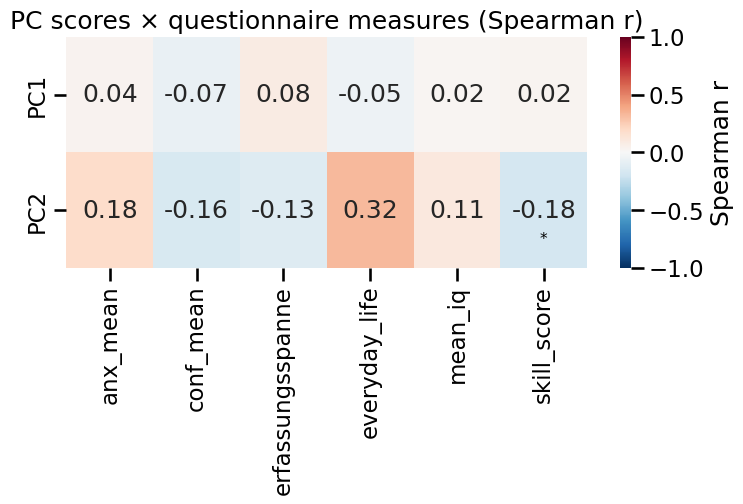

In [61]:
import pingouin

# join PC scores with questionnaires (drop group_label col first)
pc_q = scores[['PC1','PC2']].join(questionnaires, on='subject')
pc_q = pc_q.dropna()

q_vars = questionnaires.columns.tolist()
pc_vars = ['PC1', 'PC2']

# spearman correlation of each PC vs each questionnaire measure
rows = []
for pc in pc_vars:
    for q in q_vars:
        cor = pingouin.corr(pc_q[pc], pc_q[q], method='spearman')
        rows.append({'PC': pc, 'measure': q,
                     'r': cor['r'].values[0], 'p': cor['p-val'].values[0]})
corr_df = pd.DataFrame(rows)

# pivot to matrix form for heatmap
r_mat = corr_df.pivot(index='PC', columns='measure', values='r')
p_mat = corr_df.pivot(index='PC', columns='measure', values='p')

fig, ax = plt.subplots(figsize=(len(q_vars)*1.4, 3))
sns.heatmap(r_mat, annot=True, fmt='.2f', center=0, cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, cbar_kws={'label': "Spearman r"})

# mark significant cells with asterisks
for i, pc in enumerate(pc_vars):
    for j, q in enumerate(q_vars):
        p = p_mat.loc[pc, q]
        marker = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        if marker:
            ax.text(j + 0.5, i + 0.75, marker, ha='center', va='center', fontsize=11, color='k')

ax.set(title='PC scores × questionnaire measures (Spearman r)', xlabel='', ylabel='')
plt.tight_layout()

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_67123/3442344629.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_ = np.round(cor['r'][0], 2)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_67123/3442344629.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p = np.round(cor['p-val'][0], 3)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_67123/3442344629.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser

Text(0.5, 1.02, 'Correlation of PC2 with everyday life measure')

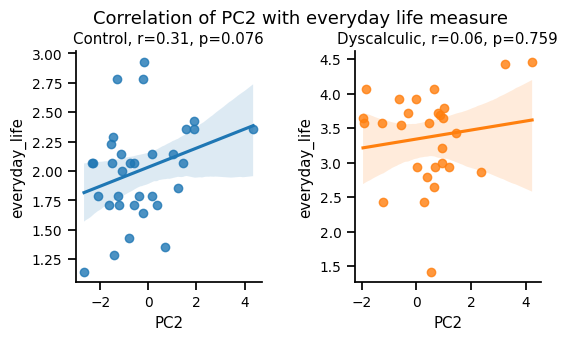

In [73]:
x_var = 'PC2'
y_var = 'everyday_life'

sns.set_context('notebook', font_scale=0.9)

fig, ax = plt.subplots(1,2,figsize=(6,3))
for i,group in enumerate(['Control', 'Dyscalculic']):
    tmp = pc_q.xs(group, level='group_label')
    cor = pingouin.corr(tmp[y_var], tmp[x_var], method = 'spearman')
    r_ = np.round(cor['r'][0], 2)
    p = np.round(cor['p-val'][0], 3)

    sns.regplot(x=x_var, y=y_var, data=tmp, ax=ax[i], color=colors[i])
    ax[i].set(title=f'{group}, r={r_}, p={p}', ylabel=y_var, xlabel=x_var)
    sns.despine()

plt.subplots_adjust(wspace=0.5)
fig.suptitle(f'Correlation of PC2 with everyday life measure', y=1.02)

## Group separation in PCA space

- **Biplot with 95% ellipses** — visual overlap/separation
- **MANOVA on PC1+PC2** — formal test of group centroid difference
- **LOO logistic regression** — classification accuracy as effect size

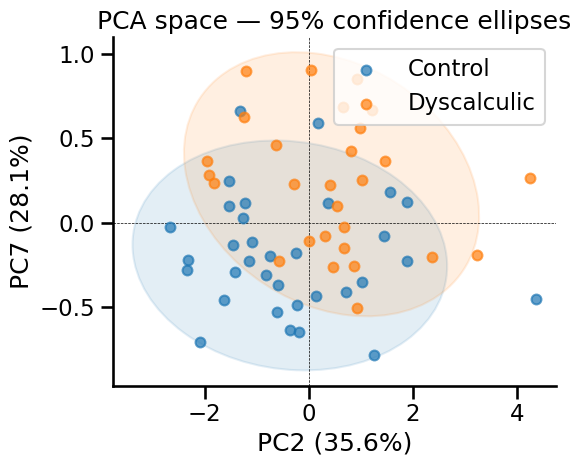

In [ ]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from statsmodels.multivariate.manova import MANOVA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import accuracy_score, roc_auc_score

def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    cov = np.cov(x, y)
    pearson = cov[0,1] / np.sqrt(cov[0,0] * cov[1,1])
    rx, ry = np.sqrt(1 + pearson), np.sqrt(1 - pearson)
    ellipse = Ellipse((0,0), width=rx*2, height=ry*2, **kwargs)
    scale_x = np.sqrt(cov[0,0]) * n_std
    scale_y = np.sqrt(cov[1,1]) * n_std
    t = transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(x.mean(), y.mean())
    ellipse.set_transform(t + ax.transData)
    ax.add_patch(ellipse)

# --- biplot PC1 × PC2 with ellipses ---
first_pc = 'PC2'
second_pc = 'PC7'  # choose another PC that shows group separation

fig, ax = plt.subplots(figsize=(6, 5))
sns.set_context('talk')

for grp, grp_df in scores.groupby('group_label'):
    ax.scatter(grp_df[first_pc], grp_df[second_pc], color=pal[grp], label=grp, alpha=0.7, s=50, zorder=3)
    confidence_ellipse(grp_df[first_pc].values, grp_df[second_pc].values, ax,
                       n_std=2.0, edgecolor=pal[grp], facecolor=pal[grp], alpha=0.12, lw=1.5)

ax.axhline(0, color='k', lw=0.5, ls='--')
ax.axvline(0, color='k', lw=0.5, ls='--')
ax.set(xlabel=f'{first_pc} ({var_exp[0]:.1f}%)', ylabel=f'{second_pc} ({var_exp[1]:.1f}%)',
       title='PCA space — 95% confidence ellipses')
ax.legend(title='')
sns.despine()
plt.tight_layout()



<Axes: >

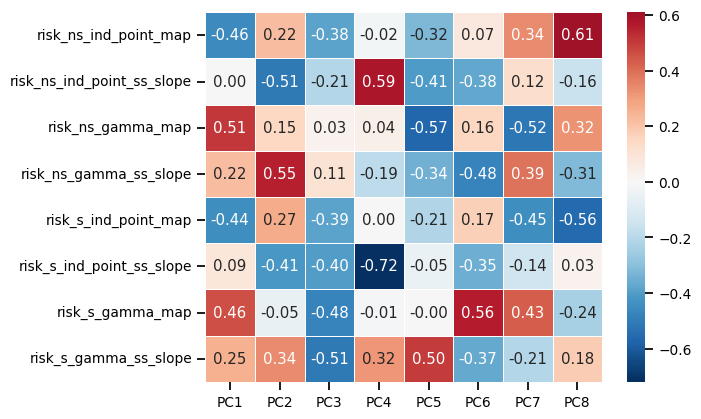

In [84]:
pc_loadings = pd.DataFrame(loadings, index=risk_cols, columns=pc_cols)
sns.heatmap(pc_loadings, cmap='RdBu_r', center=0, annot=True, fmt='.2f', linewidths=0.5)

In [76]:
print(pd.Series(loadings[:,6], index=risk_cols).sort_values(key=abs, ascending=False).round(3))

risk_ns_gamma_map            -0.519
risk_s_ind_point_map         -0.446
risk_s_gamma_map              0.432
risk_ns_gamma_ss_slope        0.391
risk_ns_ind_point_map         0.337
risk_s_gamma_ss_slope        -0.205
risk_s_ind_point_ss_slope    -0.143
risk_ns_ind_point_ss_slope    0.124
dtype: float64


 n_pcs  accuracy   auc  manova_p
     1     0.508 0.006       NaN
     2     0.623 0.593     0.114
     3     0.607 0.564     0.230
     4     0.541 0.619     0.120
     5     0.525 0.594     0.181
     6     0.541 0.609     0.025
     7     0.770 0.852     0.000
     8     0.820 0.897     0.000


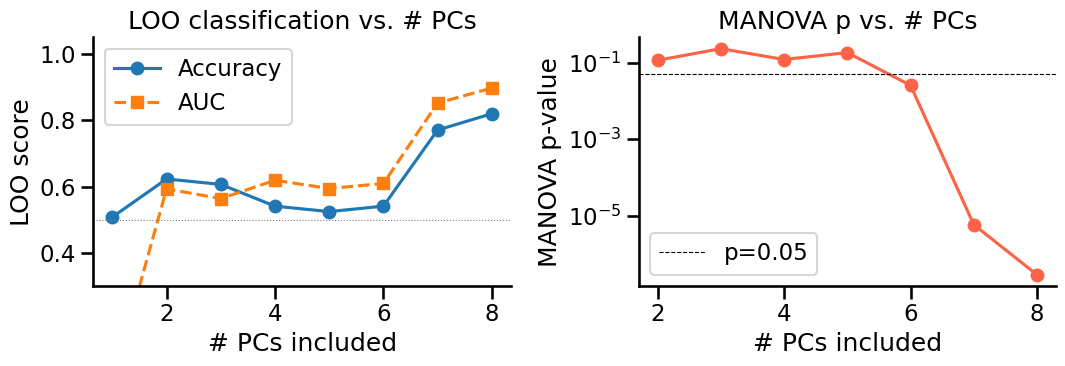

In [67]:
# --- LOO accuracy & AUC across cumulative PCs ---
n_pcs = len(risk_cols)
pc_cols = [f'PC{i+1}' for i in range(n_pcs)]
X_all = scores[pc_cols].values
y = (scores.index.get_level_values('group_label') == 'Dyscalculic').astype(int)

clf = LogisticRegression(max_iter=1000)
loo = LeaveOneOut()

accs, aucs, pvals = [], [], []
for k in range(1, n_pcs + 1):
    X_k = X_all[:, :k]
    y_pred  = cross_val_predict(clf, X_k, y, cv=loo)
    y_proba = cross_val_predict(clf, X_k, y, cv=loo, method='predict_proba')[:,1]
    accs.append(accuracy_score(y, y_pred))
    aucs.append(roc_auc_score(y, y_proba))

    # MANOVA p-value for this subset of PCs
    manova_df = scores[pc_cols[:k]].copy().reset_index()
    formula = ' + '.join(pc_cols[:k]) + ' ~ group_label'
    try:
        mv = MANOVA.from_formula(formula, data=manova_df).mv_test()
        # Wilks' lambda p-value for the intercept/group effect
        pvals.append(mv.results['group_label']['stat']['Pr > F'].iloc[0])
    except Exception:
        pvals.append(np.nan)

results_pc = pd.DataFrame({'n_pcs': range(1, n_pcs+1), 'accuracy': accs, 'auc': aucs, 'manova_p': pvals})
print(results_pc.round(3).to_string(index=False))

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.set_context('talk')

axes[0].plot(results_pc['n_pcs'], results_pc['accuracy'], 'o-', label='Accuracy')
axes[0].plot(results_pc['n_pcs'], results_pc['auc'], 's--', label='AUC')
axes[0].axhline(0.5, color='grey', lw=0.8, ls=':')
axes[0].set(xlabel='# PCs included', ylabel='LOO score', title='LOO classification vs. # PCs', ylim=(0.3, 1.05))
axes[0].legend()

axes[1].plot(results_pc['n_pcs'], results_pc['manova_p'], 'o-', color='tomato')
axes[1].axhline(0.05, color='k', lw=0.8, ls='--', label='p=0.05')
axes[1].set(xlabel='# PCs included', ylabel='MANOVA p-value', title='MANOVA p vs. # PCs', yscale='log')
axes[1].legend()

sns.despine()
plt.tight_layout()